In [4]:
import mlflow
import mlflow.lightgbm

mlflow.set_tracking_uri("sqlite:///../../mlflow.db")
mlflow.set_experiment("sentinel_pickup_disruption")

print("MLflow initialized")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")

MLflow initialized
Tracking URI: sqlite:///../../mlflow.db


In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import precision_recall_curve, roc_curve, average_precision_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from catboost import CatBoostClassifier
import xgboost as xgb
import matplotlib.pyplot as plt
import warnings
import shap
warnings.filterwarnings('ignore')

df = pd.read_parquet("../../data/processed/pickup_features.parquet")
print(f"Loaded: {df.shape}")

MODEL_FEATURES = [
    'hour_of_day', 'expected_duration', 'courier_orders_so_far',
    'day_of_week', 'accept_distance_km',
    'courier_late_rate', 'aoi_disruption_rate',
    'city_hour_rate', 'courier_city_rate',
    'aoi_type', 'city',
]
CATEGORICAL = ['city', 'aoi_type', 'day_of_week', 'hour_of_day']

train = df[df['ds'] <= 950]
test  = df[df['ds'] >= 951]

X_train = train[MODEL_FEATURES].copy()
y_train = train['is_disrupted']
X_test  = test[MODEL_FEATURES].copy()
y_test  = test['is_disrupted']

for c in CATEGORICAL:
    X_train[c] = X_train[c].astype('category')
    X_test[c]  = X_test[c].astype('category')

print(f"Train: {X_train.shape}  positives: {y_train.sum():,} ({y_train.mean()*100:.2f}%)")
print(f"Test:  {X_test.shape}  positives: {y_test.sum():,} ({y_test.mean()*100:.2f}%)")
print(f"\nBaseline PR-AUC (random) = test positive rate = {y_test.mean():.4f}")

Loaded: (6064908, 14)
Train: (4946313, 11)  positives: 90,261 (1.82%)
Test:  (1118595, 11)  positives: 20,015 (1.79%)

Baseline PR-AUC (random) = test positive rate = 0.0179


In [6]:
def log_run(run_name, params, X_train, y_train, X_test, y_test,
            categorical, feature_list, num_boost_round=2000, tags=None):
    """Train a LightGBM model and log everything to MLflow. Returns the trained model."""
    with mlflow.start_run(run_name=run_name):
        train_set = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical)
        test_set  = lgb.Dataset(X_test, label=y_test, categorical_feature=categorical, reference=train_set)
        model = lgb.train(
            params, train_set,
            num_boost_round=num_boost_round,
            valid_sets=[test_set], valid_names=['test'],
            callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)],
        )
        y_pred = model.predict(X_test, num_iteration=model.best_iteration)
        pr_auc  = average_precision_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_pred)
        mlflow.log_params(params)
        mlflow.log_param("n_features", len(feature_list))
        mlflow.log_param("features", ", ".join(feature_list))
        mlflow.log_param("best_iteration", model.best_iteration)
        mlflow.log_metric("pr_auc", pr_auc)
        mlflow.log_metric("roc_auc", roc_auc)
        mlflow.log_metric("pr_auc_lift", pr_auc / y_test.mean())
        if tags:
            mlflow.set_tags(tags)
        print(f"[{run_name}]  PR-AUC: {pr_auc:.4f}  ROC-AUC: {roc_auc:.4f}  lift: {pr_auc/y_test.mean():.1f}x  (iter {model.best_iteration})")
        return model, pr_auc, roc_auc

print("log_run defined")

log_run defined


In [7]:
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos:.1f}")

baseline_params = {
    'objective': 'binary',
    'metric': 'average_precision',
    'scale_pos_weight': scale_pos,
    'learning_rate': 0.05,
    'num_leaves': 63,
    'min_child_samples': 200,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'verbose': -1,
    'seed': 42,
}

model_baseline, pr, roc = log_run(
    run_name="baseline_10features",
    params=baseline_params,
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    categorical=CATEGORICAL,
    feature_list=MODEL_FEATURES,
    tags={"stage": "baseline", "notes": "initial 10-feature model"}
)

scale_pos_weight = 53.8
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[384]	test's average_precision: 0.132009
[baseline_10features]  PR-AUC: 0.1320  ROC-AUC: 0.8327  lift: 7.4x  (iter 384)


Test PR-AUC:  0.1320  (random baseline = 0.0179)
Test ROC-AUC: 0.8327  (random baseline = 0.5000)

Lift over random (PR-AUC): 7.4x


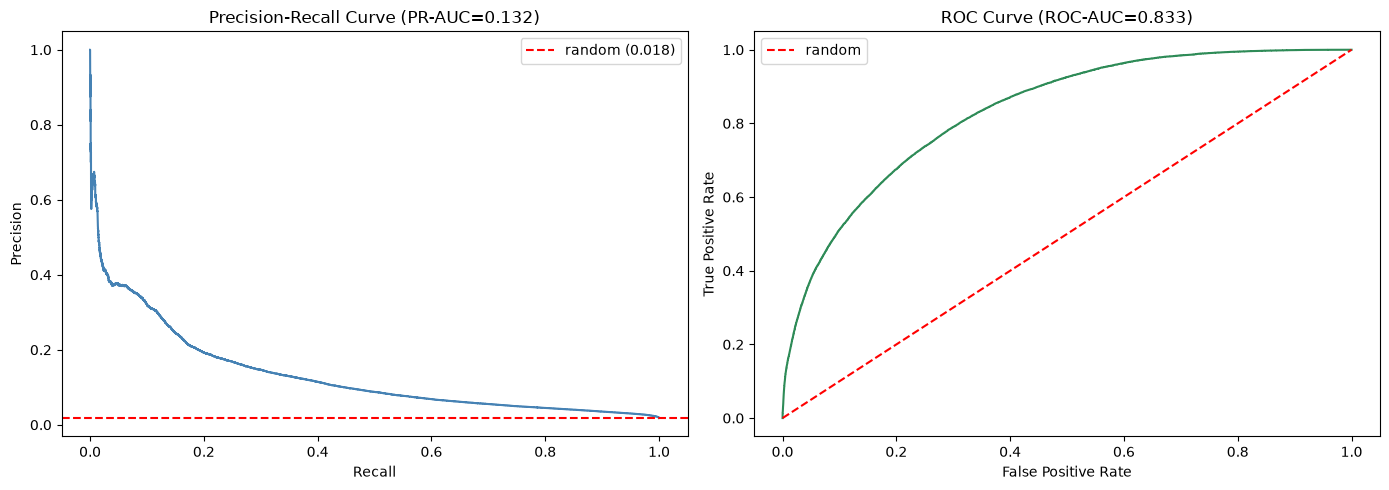

In [ ]:
y_pred = model_baseline.predict(X_test, num_iteration=model_baseline.best_iteration)

pr_auc  = average_precision_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

print(f"Test PR-AUC:  {pr_auc:.4f}  (random baseline = {y_test.mean():.4f})")
print(f"Test ROC-AUC: {roc_auc:.4f}  (random baseline = 0.5000)")
print(f"\nLift over random (PR-AUC): {pr_auc / y_test.mean():.1f}x")

from sklearn.metrics import precision_recall_curve, roc_curve
prec, rec, thresh = precision_recall_curve(y_test, y_pred)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(rec, prec, color='steelblue')
ax1.axhline(y_test.mean(), color='red', linestyle='--', label=f'random ({y_test.mean():.3f})')
ax1.set_xlabel('Recall'); ax1.set_ylabel('Precision')
ax1.set_title(f'Precision-Recall Curve (PR-AUC={pr_auc:.3f})')
ax1.legend()

fpr, tpr, _ = roc_curve(y_test, y_pred)
ax2.plot(fpr, tpr, color='seagreen')
ax2.plot([0,1],[0,1], color='red', linestyle='--', label='random')
ax2.set_xlabel('False Positive Rate'); ax2.set_ylabel('True Positive Rate')
ax2.set_title(f'ROC Curve (ROC-AUC={roc_auc:.3f})')
ax2.legend()
plt.tight_layout()
plt.show()

In [9]:
runs = mlflow.search_runs(experiment_names=["sentinel_pickup_disruption"])
print(f"Tracked runs: {len(runs)}")
if len(runs) > 0:
    print(runs[['tags.mlflow.runName', 'metrics.pr_auc', 'metrics.roc_auc']].to_string())
else:
    print("No runs logged yet — need to train through log_run()")

Tracked runs: 14
    tags.mlflow.runName  metrics.pr_auc  metrics.roc_auc
0   baseline_10features        0.132009         0.832741
1   optuna_tuned_16feat        0.219743         0.878713
2       catboost_16feat        0.201502         0.878111
3        xgboost_16feat        0.210106         0.877255
4         logreg_16feat        0.190694         0.844351
5     v3_ablated_16feat        0.218773         0.878152
6         v2_21features        0.218402         0.877674
7   baseline_10features        0.132009         0.832741
8       catboost_16feat        0.201502         0.878111
9        xgboost_16feat        0.210106         0.877255
10        logreg_16feat        0.190694         0.844351
11    v3_ablated_16feat        0.218773         0.878152
12        v2_21features        0.218402         0.877674
13  baseline_10features        0.132009         0.832741


In [10]:
df = pd.read_parquet("../../data/processed/pickup_features_v2.parquet")
print(f"Loaded: {df.shape}")

MODEL_FEATURES_V2 = [
    'hour_of_day', 'expected_duration', 'courier_orders_so_far',
    'day_of_week', 'accept_distance_km',
    'courier_late_rate', 'aoi_disruption_rate', 'city_hour_rate', 'courier_city_rate',
    'aoi_type',
    'courier_zone_familiarity', 'courier_tenure_days', 'courier_load_3h',
    'mins_since_last_accept', 'velocity_target', 'is_first_order_of_day',
    'is_rush', 'is_far',
    'courier_running_rate', 'zone_running_rate', 'orders_per_courier',
    'city',
]
CATEGORICAL = ['city', 'aoi_type', 'day_of_week', 'hour_of_day', 'is_rush', 'is_far', 'is_first_order_of_day']

train = df[df['ds'] <= 950]
test  = df[df['ds'] >= 951]

X_train = train[MODEL_FEATURES_V2].copy()
y_train = train['is_disrupted']
X_test  = test[MODEL_FEATURES_V2].copy()
y_test  = test['is_disrupted']

for c in CATEGORICAL:
    X_train[c] = X_train[c].astype('category')
    X_test[c]  = X_test[c].astype('category')

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Features: {len(MODEL_FEATURES_V2)}")

Loaded: (6064908, 25)
Train: (4946313, 22), Test: (1118595, 22)
Features: 22


In [11]:
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

v2_params = {
    'objective': 'binary',
    'metric': 'average_precision',
    'scale_pos_weight': scale_pos,
    'learning_rate': 0.05,
    'num_leaves': 63,
    'min_child_samples': 200,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'verbose': -1,
    'seed': 42,
}

model_v2, pr_v2, roc_v2 = log_run(
    run_name="v2_21features",
    params=v2_params,
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    categorical=CATEGORICAL,
    feature_list=MODEL_FEATURES_V2,
    tags={"stage": "feature_expansion", "notes": "added 11 new features"}
)

print(f"\n--- COMPARISON ---")
print(f"Baseline (10 feat): PR-AUC 0.1320")
print(f"V2 (21 feat):       PR-AUC {pr_v2:.4f}")
print(f"Change: {(pr_v2 - 0.1320):+.4f} ({(pr_v2/0.1320 - 1)*100:+.1f}%)")

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[473]	test's average_precision: 0.218402
[v2_21features]  PR-AUC: 0.2184  ROC-AUC: 0.8777  lift: 12.2x  (iter 473)

--- COMPARISON ---
Baseline (10 feat): PR-AUC 0.1320
V2 (21 feat):       PR-AUC 0.2184
Change: +0.0864 (+65.5%)


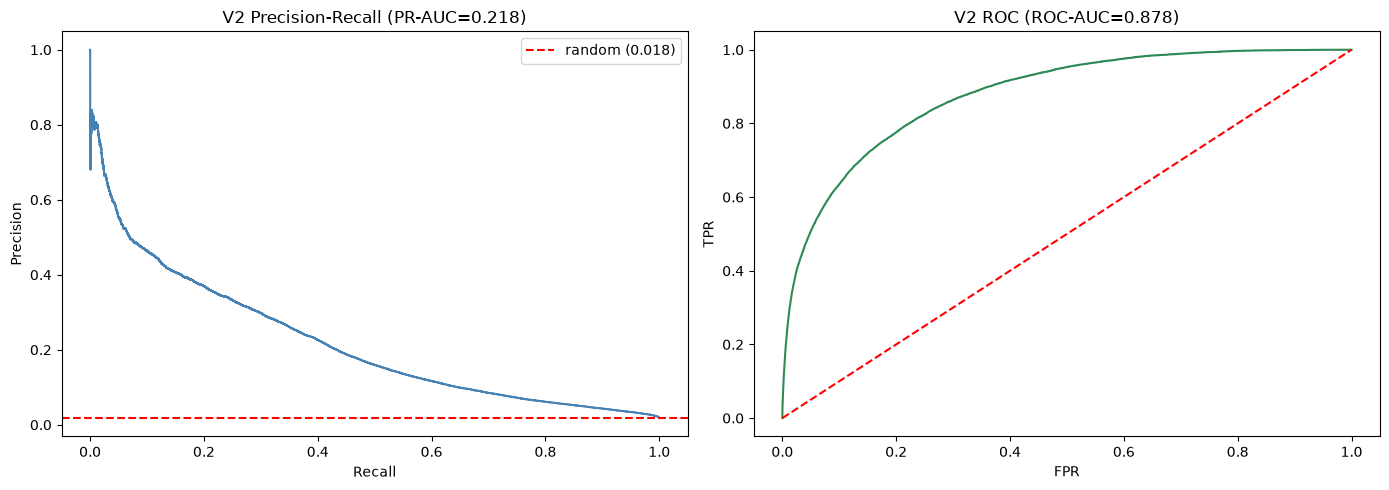

In [ ]:
y_pred = model_v2.predict(X_test, num_iteration=model_v2.best_iteration)

pr_auc = average_precision_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
prec, rec, _ = precision_recall_curve(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_pred)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(rec, prec, color='steelblue')
ax1.axhline(y_test.mean(), color='red', linestyle='--', label=f'random ({y_test.mean():.3f})')
ax1.set_xlabel('Recall'); ax1.set_ylabel('Precision')
ax1.set_title(f'V2 Precision-Recall (PR-AUC={pr_auc:.3f})'); ax1.legend()
ax2.plot(fpr, tpr, color='seagreen')
ax2.plot([0,1],[0,1], color='red', linestyle='--')
ax2.set_xlabel('FPR'); ax2.set_ylabel('TPR')
ax2.set_title(f'V2 ROC (ROC-AUC={roc_auc:.3f})')
plt.tight_layout(); plt.show()

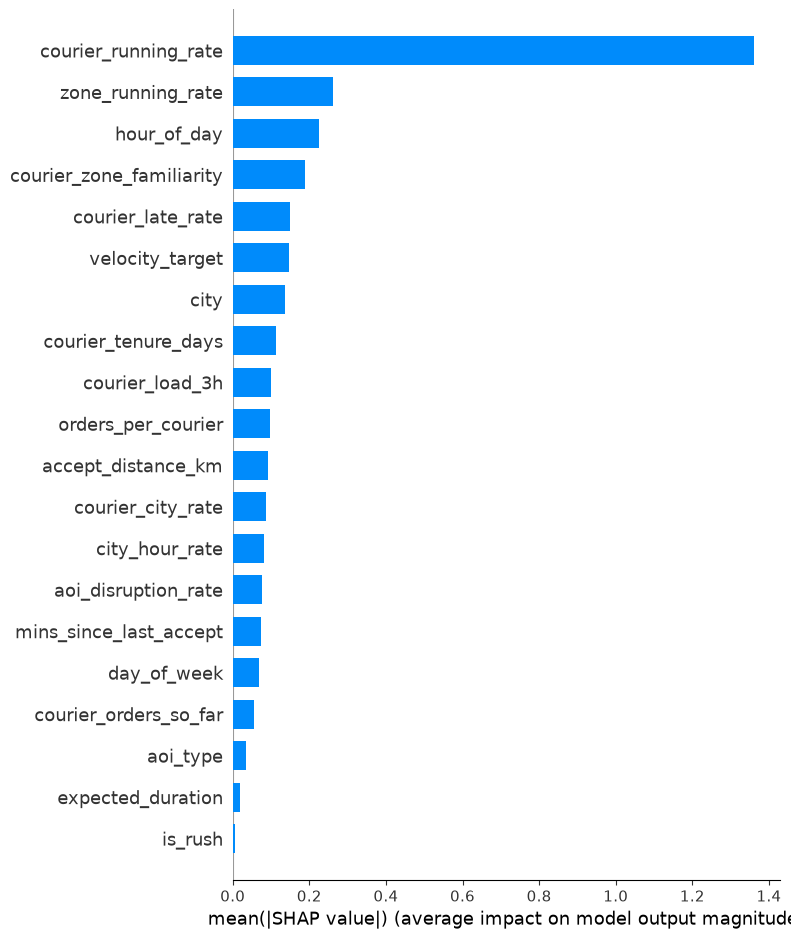

In [ ]:
sample = X_test.sample(n=50000, random_state=42)

explainer = shap.TreeExplainer(model_v2)
shap_values = explainer.shap_values(sample)

shap.summary_plot(shap_values, sample, plot_type='bar', show=True)

In [ ]:
DROP_CANDIDATES = ['is_rush', 'is_far', 'is_first_order_of_day', 'expected_duration', 'aoi_type']

MODEL_FEATURES_ABLATED = [f for f in MODEL_FEATURES_V2 if f not in DROP_CANDIDATES]
CATEGORICAL_ABLATED = [c for c in CATEGORICAL if c not in DROP_CANDIDATES]

X_train_ab = train[MODEL_FEATURES_ABLATED].copy()
X_test_ab  = test[MODEL_FEATURES_ABLATED].copy()
for c in CATEGORICAL_ABLATED:
    X_train_ab[c] = X_train_ab[c].astype('category')
    X_test_ab[c]  = X_test_ab[c].astype('category')

model_ab, pr_ab, roc_ab = log_run(
    run_name="v3_ablated_16feat",
    params=v2_params,
    X_train=X_train_ab, y_train=y_train,
    X_test=X_test_ab, y_test=y_test,
    categorical=CATEGORICAL_ABLATED,
    feature_list=MODEL_FEATURES_ABLATED,
    tags={"stage": "ablation", "notes": "dropped 5 lowest-SHAP features"}
)

print(f"\n--- ABLATION COMPARISON ---")
print(f"V2 (21 feat): PR-AUC 0.2184")
print(f"V3 (16 feat): PR-AUC {pr_ab:.4f}")
print(f"Change: {(pr_ab - 0.2184):+.4f}")
print(f"Features dropped: {DROP_CANDIDATES}")

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[272]	test's average_precision: 0.218773
[v3_ablated_16feat]  PR-AUC: 0.2188  ROC-AUC: 0.8782  lift: 12.2x  (iter 272)

--- ABLATION COMPARISON ---
V2 (21 feat): PR-AUC 0.2184
V3 (16 feat): PR-AUC 0.2188
Change: +0.0004
Features dropped: ['is_rush', 'is_far', 'is_first_order_of_day', 'expected_duration', 'aoi_type']


In [ ]:
num_feats = [f for f in MODEL_FEATURES_ABLATED if f not in CATEGORICAL_ABLATED]
cat_feats = CATEGORICAL_ABLATED

X_tr_lr = pd.get_dummies(train[MODEL_FEATURES_ABLATED], columns=cat_feats, dummy_na=False)
X_te_lr = pd.get_dummies(test[MODEL_FEATURES_ABLATED], columns=cat_feats, dummy_na=False)
X_te_lr = X_te_lr.reindex(columns=X_tr_lr.columns, fill_value=0) 

imp = SimpleImputer(strategy='median')
scaler = StandardScaler()
X_tr_lr_s = scaler.fit_transform(imp.fit_transform(X_tr_lr))
X_te_lr_s = scaler.transform(imp.transform(X_te_lr))

with mlflow.start_run(run_name="logreg_16feat"):
    lr = LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0)
    lr.fit(X_tr_lr_s, y_train)
    p_lr = lr.predict_proba(X_te_lr_s)[:, 1]
    pr_lr = average_precision_score(y_test, p_lr)
    roc_lr = roc_auc_score(y_test, p_lr)
    mlflow.log_metric("pr_auc", pr_lr)
    mlflow.log_metric("roc_auc", roc_lr)
    mlflow.set_tags({"model_family": "logistic_regression"})
    print(f"[LogReg]  PR-AUC: {pr_lr:.4f}  ROC-AUC: {roc_lr:.4f}")

X_tr_xgb = train[MODEL_FEATURES_ABLATED].copy()
X_te_xgb = test[MODEL_FEATURES_ABLATED].copy()
for c in cat_feats:
    X_tr_xgb[c] = X_tr_xgb[c].astype('category').cat.codes
    X_te_xgb[c] = X_te_xgb[c].astype('category').cat.codes

with mlflow.start_run(run_name="xgboost_16feat"):
    xgb_model = xgb.XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=7,
        scale_pos_weight=scale_pos, subsample=0.8, colsample_bytree=0.8,
        eval_metric='aucpr', early_stopping_rounds=50, tree_method='hist',
        random_state=42
    )
    xgb_model.fit(X_tr_xgb, y_train, eval_set=[(X_te_xgb, y_test)], verbose=False)
    p_xgb = xgb_model.predict_proba(X_te_xgb)[:, 1]
    pr_xgb = average_precision_score(y_test, p_xgb)
    roc_xgb = roc_auc_score(y_test, p_xgb)
    mlflow.log_metric("pr_auc", pr_xgb)
    mlflow.log_metric("roc_auc", roc_xgb)
    mlflow.set_tags({"model_family": "xgboost"})
    print(f"[XGBoost]  PR-AUC: {pr_xgb:.4f}  ROC-AUC: {roc_xgb:.4f}")

print(f"\n--- MODEL COMPARISON (16 features) ---")
print(f"LightGBM:  PR-AUC 0.2188")
print(f"XGBoost:   PR-AUC {pr_xgb:.4f}")
print(f"LogReg:    PR-AUC {pr_lr:.4f}")

[LogReg]  PR-AUC: 0.1907  ROC-AUC: 0.8444
[XGBoost]  PR-AUC: 0.2101  ROC-AUC: 0.8773

--- MODEL COMPARISON (16 features) ---
LightGBM:  PR-AUC 0.2188
XGBoost:   PR-AUC 0.2101
LogReg:    PR-AUC 0.1907


In [ ]:
X_tr_cat = train[MODEL_FEATURES_ABLATED].copy()
X_te_cat = test[MODEL_FEATURES_ABLATED].copy()

cat_idx = [X_tr_cat.columns.get_loc(c) for c in CATEGORICAL_ABLATED]
for c in CATEGORICAL_ABLATED:
    X_tr_cat[c] = X_tr_cat[c].astype(str)
    X_te_cat[c] = X_te_cat[c].astype(str)

with mlflow.start_run(run_name="catboost_16feat"):
    cat_model = CatBoostClassifier(
        iterations=500, learning_rate=0.05, depth=7,
        scale_pos_weight=scale_pos, eval_metric='PRAUC',
        random_seed=42, verbose=False
    )
    cat_model.fit(X_tr_cat, y_train, cat_features=cat_idx,
                  eval_set=(X_te_cat, y_test), early_stopping_rounds=50)
    p_cat = cat_model.predict_proba(X_te_cat)[:, 1]
    pr_cat = average_precision_score(y_test, p_cat)
    roc_cat = roc_auc_score(y_test, p_cat)
    mlflow.log_metric("pr_auc", pr_cat)
    mlflow.log_metric("roc_auc", roc_cat)
    mlflow.set_tags({"model_family": "catboost"})
    print(f"[CatBoost]  PR-AUC: {pr_cat:.4f}  ROC-AUC: {roc_cat:.4f}")

print(f"\n--- FULL MODEL COMPARISON (16 features) ---")
print(f"LightGBM:  PR-AUC 0.2188")
print(f"XGBoost:   PR-AUC 0.2101")
print(f"CatBoost:  PR-AUC {pr_cat:.4f}")
print(f"LogReg:    PR-AUC 0.1907")

[CatBoost]  PR-AUC: 0.2015  ROC-AUC: 0.8781

--- FULL MODEL COMPARISON (16 features) ---
LightGBM:  PR-AUC 0.2188
XGBoost:   PR-AUC 0.2101
CatBoost:  PR-AUC 0.2015
LogReg:    PR-AUC 0.1907


In [17]:
print("log_run:", 'log_run' in dir())
print("X_train_ab:", 'X_train_ab' in dir())
print("X_test_ab:", 'X_test_ab' in dir())
print("y_train:", 'y_train' in dir())
print("y_test:", 'y_test' in dir())
print("CATEGORICAL_ABLATED:", 'CATEGORICAL_ABLATED' in dir())
print("MODEL_FEATURES_ABLATED:", 'MODEL_FEATURES_ABLATED' in dir())
print("scale_pos:", 'scale_pos' in dir())

log_run: True
X_train_ab: True
X_test_ab: True
y_train: True
y_test: True
CATEGORICAL_ABLATED: True
MODEL_FEATURES_ABLATED: True
scale_pos: True


In [18]:
best_params = {
    'learning_rate': 0.0350680557665666,
    'num_leaves': 161,
    'max_depth': 8,
    'min_child_samples': 393,
    'feature_fraction': 0.5636286299455864,
    'bagging_fraction': 0.623902034768071,
    'bagging_freq': 2,
    'lambda_l1': 5.342888024649934e-05,
    'lambda_l2': 0.2695979173310363,
    'min_gain_to_split': 0.8394828145550448,
    'objective': 'binary',
    'metric': 'average_precision',
    'scale_pos_weight': scale_pos,
    'verbose': -1,
    'seed': 42,
}

model_tuned, pr_tuned, roc_tuned = log_run(
    run_name="optuna_tuned_16feat",
    params=best_params,
    X_train=X_train_ab, y_train=y_train,
    X_test=X_test_ab, y_test=y_test,
    categorical=CATEGORICAL_ABLATED,
    feature_list=MODEL_FEATURES_ABLATED,
    tags={"stage": "tuned", "notes": "optuna 30 trials"}
)

print(f"\n--- TUNING RESULT (test set) ---")
print(f"Default params (v3): PR-AUC 0.2188")
print(f"Optuna tuned:        PR-AUC {pr_tuned:.4f}")
print(f"Change: {(pr_tuned - 0.2188):+.4f}")

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[388]	test's average_precision: 0.219743
[optuna_tuned_16feat]  PR-AUC: 0.2197  ROC-AUC: 0.8787  lift: 12.3x  (iter 388)

--- TUNING RESULT (test set) ---
Default params (v3): PR-AUC 0.2188
Optuna tuned:        PR-AUC 0.2197
Change: +0.0009


In [ ]:
p_lgb = model_tuned.predict(X_test_ab, num_iteration=model_tuned.best_iteration)

X_te_xgb = test[MODEL_FEATURES_ABLATED].copy()
for c in CATEGORICAL_ABLATED:
    X_te_xgb[c] = X_te_xgb[c].astype('category').cat.codes
p_xgb = xgb_model.predict_proba(X_te_xgb)[:, 1]

X_te_cat = test[MODEL_FEATURES_ABLATED].copy()
for c in CATEGORICAL_ABLATED:
    X_te_cat[c] = X_te_cat[c].astype(str)
p_cat = cat_model.predict_proba(X_te_cat)[:, 1]

ens_lgb_xgb = (p_lgb + p_xgb) / 2
ens_all3    = (p_lgb + p_xgb + p_cat) / 3
ens_weighted = 0.6*p_lgb + 0.25*p_xgb + 0.15*p_cat

print("--- ENSEMBLE TEST (vs tuned LightGBM 0.2197) ---")
for name, pred in [
    ("LightGBM alone",      p_lgb),
    ("LGB + XGB (avg)",     ens_lgb_xgb),
    ("LGB+XGB+Cat (avg)",   ens_all3),
    ("Weighted 60/25/15",   ens_weighted),
]:
    pr = average_precision_score(y_test, pred)
    roc = roc_auc_score(y_test, pred)
    print(f"  {name:22s} PR-AUC {pr:.4f}  ROC-AUC {roc:.4f}")

--- ENSEMBLE TEST (vs tuned LightGBM 0.2197) ---
  LightGBM alone         PR-AUC 0.2197  ROC-AUC 0.8787
  LGB + XGB (avg)        PR-AUC 0.2185  ROC-AUC 0.8796
  LGB+XGB+Cat (avg)      PR-AUC 0.2156  ROC-AUC 0.8798
  Weighted 60/25/15      PR-AUC 0.2187  ROC-AUC 0.8798


In [ ]:
import joblib
import json
from pathlib import Path

MODEL_DIR = Path("../../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

model_tuned.save_model(str(MODEL_DIR / "pickup_disruption_lgbm.txt"))

metadata = {
    "model_type": "lightgbm",
    "features": MODEL_FEATURES_ABLATED,
    "categorical_features": CATEGORICAL_ABLATED,
    "best_params": best_params,
    "metrics": {
        "pr_auc": float(pr_tuned),
        "roc_auc": float(roc_tuned),
        "test_positive_rate": float(y_test.mean()),
        "pr_auc_lift": float(pr_tuned / y_test.mean()),
    },
    "best_iteration": int(model_tuned.best_iteration),
    "train_split": "ds <= 950",
    "test_split": "ds >= 951",
    "global_disruption_rate": float(y_train.mean()),
}
with open(MODEL_DIR / "pickup_model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved:")
print(f"  {MODEL_DIR / 'pickup_disruption_lgbm.txt'}")
print(f"  {MODEL_DIR / 'pickup_model_metadata.json'}")
print(f"\nFinal model: PR-AUC {pr_tuned:.4f}, ROC-AUC {roc_tuned:.4f}, {model_tuned.best_iteration} trees")

Saved:
  ../../models/pickup_disruption_lgbm.txt
  ../../models/pickup_model_metadata.json

Final model: PR-AUC 0.2197, ROC-AUC 0.8787, 388 trees


In [ ]:
joblib.dump(model_tuned, "../../models/pickup_disruption_lgbm.pkl")

['../../models/pickup_disruption_lgbm.pkl']